In [1]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
ds = pd.read_csv("../seminars/S12-hw-dataset.csv")

In [5]:
ds["date"] = pd.to_datetime(ds["date"], errors="coerce")
ds

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [6]:
ds.sort_values("date").reset_index(drop = True)

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [7]:
ds["date_date"] = ds["date"].dt.date

In [8]:
ds

,date,target,date_date
0,2025-01-01 00:00:00,98.14,2025-01-01
1,2025-01-01 01:00:00,98.07,2025-01-01
2,2025-01-01 02:00:00,104.70,2025-01-01
3,2025-01-01 03:00:00,112.81,2025-01-01
4,2025-01-01 04:00:00,112.62,2025-01-01
...,...,...,...
4315,2025-06-29 19:00:00,153.05,2025-06-29
4316,2025-06-29 20:00:00,134.23,2025-06-29
4317,2025-06-29 21:00:00,137.68,2025-06-29
4318,2025-06-29 22:00:00,126.53,2025-06-29


In [9]:
graph_ds =  ds.groupby(ds["date_date"])["target"].median().reset_index()

In [10]:
graph_ds.shape

(180, 2)

sanity-check по данным

In [11]:
print(ds.dtypes)

date         datetime64[ns]
target              float64
date_date            object
dtype: object


In [12]:
ds.shape

(4320, 3)

In [13]:
ds.describe()

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [14]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       4320 non-null   datetime64[ns]
 1   target     4320 non-null   float64       
 2   date_date  4320 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 101.4+ KB


In [15]:
ds.isna().sum()

date         0
target       0
date_date    0
dtype: int64

График ряда

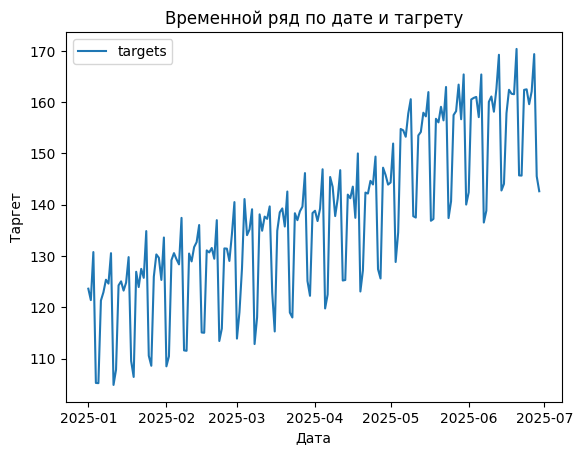

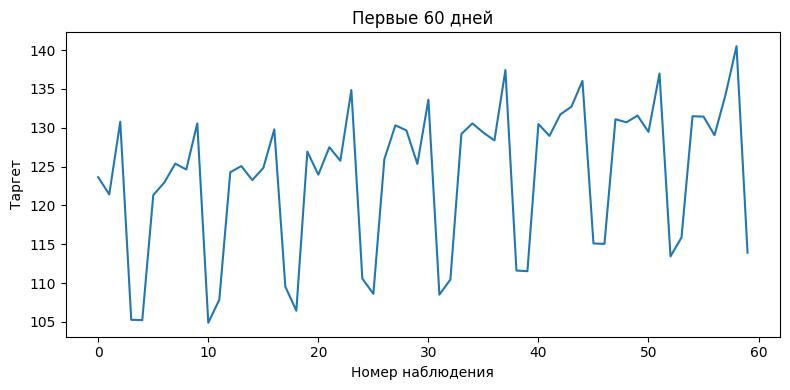

In [16]:
fig, ax = plt.subplots()
ax.plot(graph_ds["date_date"], graph_ds["target"], lw = 1.5, label = "targets")
ax.set_title("Временной ряд по дате и тагрету")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
graph_ds["target"].iloc[:60].plot(ax = axes, title = "Первые 60 дней")
axes.set_xlabel("Номер наблюдения")
axes.set_ylabel("Таргет")
plt.tight_layout()
plt.show()



Выводы о графике:

Тренд:
Выражен явно восходящий тренд, линейный рост таргета.

Сезонность:
Четко видна периодическая компонента, регулярные колебания с постоянной частотой. Видна недельная сезонность, пики и спады повторяются циклично.

Выбросы:
Выраженных выбросов не наблюдается, ряд ведет себя предсказуемо.

Нестационарность:
Ряд явно нестационарен, потому что наблюдается недельная сезонность, а также явно восходящий тренд относительно всей прямой

In [17]:
@dataclass
class SplitConfig:
    train_frac: float = 0.7
    val_frac: float = 0.15
    test_frac: float = 0.15

In [18]:
def temporal_split(df, cfg = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = df.shape[0]
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(ds)

In [19]:
print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


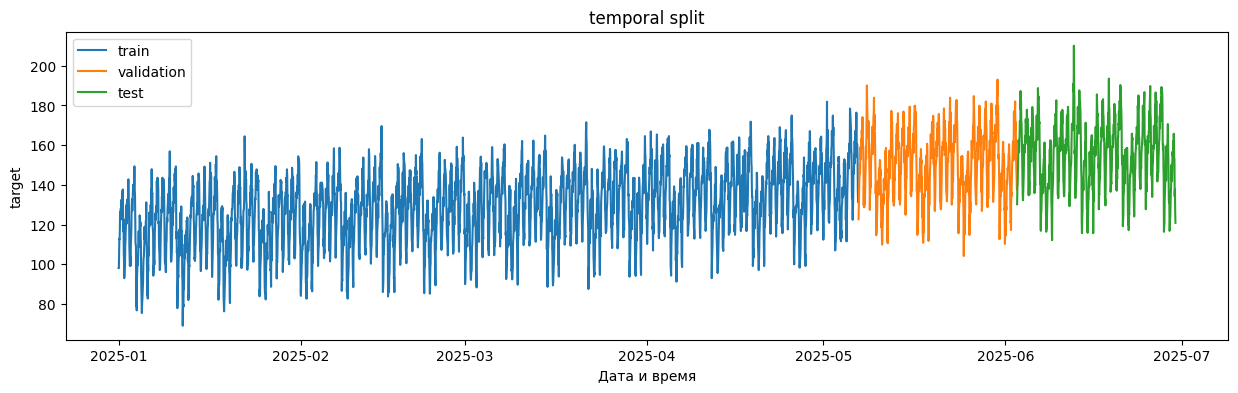

In [20]:
fig, ax = plt.subplots(figsize = (15, 4))

ax.plot(train_df["date"], train_df["target"], label = "train")
ax.plot(val_df["date"], val_df["target"], label = "validation")
ax.plot(test_df["date"], test_df["target"], label = "test")
ax.set_title("temporal split")
ax.set_xlabel("Дата и время")
ax.set_ylabel("target")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

Для это задачи random split будте некорректен, потому что сама суть задачи это по данным прошлого предсказать будущее, но если мы рандомно разделяем данные, то модель будет смотреть в будущее и корректное предсказание не получится.

In [21]:
def add_calendar_features(df):
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek

    out["dow_sin"] = np.sin(2* np.pi * out["dayofweek"]/7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"]/7)

    return out

In [22]:
def add_lag_features(df, target_col = "target"):
    out = df.copy()

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window = 7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window = 7).std()
    return out

features_df = add_calendar_features(ds)
features_df = add_lag_features(features_df)

In [23]:
features_df = features_df.dropna().reset_index(drop = True)

In [24]:
feature_cols = [
    "dayofweek", 
    "dow_sin", "dow_cos",
    "lag_1", "lag_7", "lag_14", 
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

In [25]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

X_train: (3014, 8) | y_train: (3014,)
X_val:   (646, 8) | y_val:   (646,)
X_test:  (646, 8) | y_test:  (646,)


Метрики

In [26]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def evaluate_regression(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }])

B1 (naive-last): наивный baseline, где прогноз равен последнему известному значению.

In [27]:
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)")
], ignore_index=True)


print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE
0,Naive (lag_1),6.443406,8.203532,4.394594


B2 (moving-average): baseline на основе скользящего среднего по окну разумного размера

In [28]:
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)


print("Validation:")
display(baseline_results_val)


Validation:


,model,MAE,RMSE,MAPE
0,MovingAverage(7),12.723717,15.236326,8.828779


B3 (ridge-lag-features): Ridge (или LinearRegression) на лаговых, rolling- и календарных признаках.

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

ridge = Ridge(alpha = 1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)


val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)


Validation:


,model,MAE,RMSE,MAPE
0,Ridge,7.638767,9.146881,5.090831
1,MovingAverage(7),12.723717,15.236326,8.828779


R1 (gru-forecast): GRU на оконном представлении ряда.

In [30]:
window_size = 28 

In [31]:
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test


In [32]:
def make_windows(series_2d, window_size):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i:i+window_size])
        y.append(series_2d[i+window_size, 0])
    return np.array(X, dtype = np.float32), np.array(y, dtype = np.float32)

In [33]:
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled , window_size)

In [34]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64

In [35]:
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)


train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем


xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [36]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

model =  GRUForecaster(input_size=1, hidden_size=32, num_layers=1, dropout=0.0)
print(model)

GRUForecaster(
  (rnn): GRU(1, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)


In [37]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"mae": mae, "rmse": rmse}

In [38]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    all_preds, all_true = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

In [39]:
def fit_model(model, train_loader, val_loader, epochs = 12, lr = 1e-3, device = device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

        val_loss = evaluate_loss(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [44]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)


GRU  params: 37889
Epoch 01 | train_loss=0.6851 | val_loss=0.5924
Epoch 02 | train_loss=0.2544 | val_loss=0.2088
Epoch 03 | train_loss=0.1637 | val_loss=0.1853
Epoch 04 | train_loss=0.1538 | val_loss=0.1788
Epoch 05 | train_loss=0.1511 | val_loss=0.2000
Epoch 06 | train_loss=0.1512 | val_loss=0.1913
Epoch 07 | train_loss=0.1478 | val_loss=0.2016
Epoch 08 | train_loss=0.1463 | val_loss=0.2030
Epoch 09 | train_loss=0.1466 | val_loss=0.2318
Epoch 10 | train_loss=0.1457 | val_loss=0.1980
Epoch 11 | train_loss=0.1442 | val_loss=0.2580
Epoch 12 | train_loss=0.1455 | val_loss=0.2070
Epoch 13 | train_loss=0.1432 | val_loss=0.1849
Epoch 14 | train_loss=0.1402 | val_loss=0.1915
Epoch 15 | train_loss=0.1347 | val_loss=0.1902
Epoch 16 | train_loss=0.1250 | val_loss=0.1913
Epoch 17 | train_loss=0.1137 | val_loss=0.2434
Epoch 18 | train_loss=0.1101 | val_loss=0.2178
Epoch 19 | train_loss=0.1113 | val_loss=0.2565
Epoch 20 | train_loss=0.1061 | val_loss=0.2755
Epoch 21 | train_loss=0.1081 | val_loss=0

In [46]:
torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")

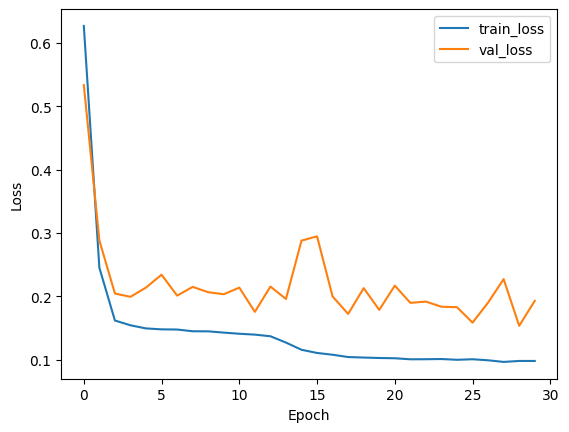

In [ ]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label = "train_loss")
ax.plot(gru_history["val_loss"], label = "val_loss")
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()
